In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import xtrack as xt

In [2]:
def twiss_scan(line: xt.Line, delta_grid: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    tw0 = line.twiss4d(delta0=0.0)
    rows: list[tuple[float, float, float]] = [(0.0, float(tw0.qx), float(tw0.qy))]

    co_prev = tw0.particle_on_co
    neg_rows: list[tuple[float, float, float]] = []
    for delta in delta_grid[delta_grid < 0][::-1]:
        try:
            tw = line.twiss4d(delta0=float(delta), co_guess=co_prev)
            co_prev = tw.particle_on_co
            neg_rows.append((float(delta), float(tw.qx), float(tw.qy)))
        except Exception as e:
            neg_rows.append((float(delta), np.nan, np.nan))

    co_prev = tw0.particle_on_co
    pos_rows: list[tuple[float, float, float]] = []
    for delta in delta_grid[delta_grid > 0]:
        try:
            tw = line.twiss4d(delta0=float(delta), co_guess=co_prev)
            co_prev = tw.particle_on_co
            pos_rows.append((float(delta), float(tw.qx), float(tw.qy)))
        except Exception as e:
            pos_rows.append((float(delta), np.nan, np.nan))

    rows = neg_rows[::-1] + rows + pos_rows
    d = np.array([r[0] for r in rows], dtype=float)
    qx = np.array([r[1] for r in rows], dtype=float)
    qy = np.array([r[2] for r in rows], dtype=float)
    return d, qx, qy

In [14]:
qx0 = 20.13
qy0 = 20.18
xi_x = 0.5
xi_y = 0.5

In [15]:
line_ref = xt.load('sps_with_aperture_inj_q20_beam_sagitta4.json')
env_ref = line_ref.env
cavity_elements, cavity_names = line_ref.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line_ref[name].frequency = 200e6
    line_ref[name].lag = 180
    line_ref[name].voltage = 0
line_ref['actcse.31632'].voltage = 3.0e6

line_ref.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx0,       qy=qy0,     tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=xi_x*qx0, dqy=xi_y*qy0, tol=1e-2, tag="chrom"),
        ],
    )

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 14.2                              
Matching: model call n. 29 penalty = 4.4812e-03              
Optimize - end penalty:  0.00448121                            


In [27]:
line = xt.load('sps_with_aperture_inj_q20_beam_sagitta4.json')
env = line.env
cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
line['actcse.31632'].voltage = 3.0e6

error_variants = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

env.vars["qph_setvalue"] = 0.0
env.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3,   b4*0.,       b5*-5.74,  b6*0.])
for nn in mbb:
    env[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3,  b4*0.,       b5*-5.10,  b6*0.])
for nn in qf:
    env[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*0.75e-1,  b5*0.,     b6*-0.87e3])
for nn in qd:
    env[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-2.03e-1, b5*0.,     b6*2.04e3])


env.vars["qph_setvalue"] = xi_x
env.vars["qpv_setvalue"] = xi_y
line.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx0,       qy=qy0,     tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=xi_x*qx0, dqy=xi_y*qy0, tol=1e-2, tag="chrom"),
        ],
    )

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 13.08                             
Matching: model call n. 57 penalty = 5.6906e-03              
Optimize - end penalty:  0.00569058                            


In [33]:
delta_grid = np.linspace(-0.006, 0.006, 81)
d, qx, qy = twiss_scan(line, delta_grid)
d_ref, qx_ref, qy_ref = twiss_scan(line_ref, delta_grid)

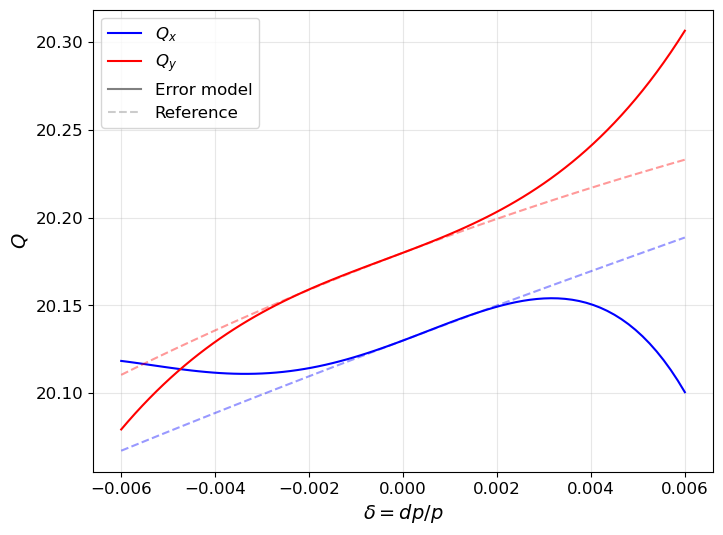

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))

# Error model lines
ax.plot(d, qx, label="Qx", color='blue', linestyle='-')
ax.plot(d, qy, label="Qy", color='red', linestyle='-')

# Reference lines (lighter alpha)
ax.plot(d_ref, qx_ref, label="Qx (reference)", color='blue', alpha=0.4, linestyle='--')
ax.plot(d_ref, qy_ref, label="Qy (reference)", color='red', alpha=0.4, linestyle='--')

ax.tick_params(axis='both', labelsize=12)
legend_elements = [
    Line2D([0], [0], color='blue', label=r'$Q_x$'),
    Line2D([0], [0], color='red', label=r'$Q_y$'),
    Line2D([0], [0], color='gray', linestyle='-', label='Error model'),
    Line2D([0], [0], color='gray', linestyle='--', alpha=0.4, label='Reference'),
]
ax.legend(handles=legend_elements, fontsize=12, loc='upper left')

ax.set_xlabel(r'$\delta = dp/p$', fontsize=14)
ax.set_ylabel(r'$Q$', fontsize=14)
ax.grid(True, alpha=0.3)

In [46]:
lines = {}
dds = {}
qxs = {}
qys = {}

for tt in error_variants.keys():
    print(f"Variant: {tt}, b1={b1}, b2={b2}, b3={b3}, b4={b4}, b5={b5}, b6={b6}")
    lines[tt] = xt.load('sps_with_aperture_inj_q20_beam_sagitta4.json')
    env_loc = lines[tt].env
    for name in cavity_names:
        lines[tt][name].frequency = 200e6
        lines[tt][name].lag = 180
        lines[tt][name].voltage = 0
    lines[tt]['actcse.31632'].voltage = 3.0e6
    b1, b2, b3, b4, b5, b6 = error_variants[tt]
    tte = env_loc.elements.get_table()
    mask_rbends = tte.element_type == "RBend"
    mask_quads  = tte.element_type == "Quadrupole"
    mba = tte.rows[mask_rbends].rows["mba.*"].name
    mbb = tte.rows[mask_rbends].rows["mbb.*"].name
    qf  = tte.rows[mask_quads].rows["qf.*"].name
    qd  = tte.rows[mask_quads].rows["qd.*"].name
    for nn in mba:
        env_loc[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3,   b4*0.,       b5*-5.74,  b6*0.])
    for nn in mbb:
        env_loc[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3,  b4*0.,       b5*-5.10,  b6*0.])
    for nn in qf:
        env_loc[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*0.75e-1,  b5*0.,     b6*-0.87e3])
    for nn in qd:
        env_loc[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-2.03e-1, b5*0.,     b6*2.04e3])
    env_loc.vars["qph_setvalue"] = xi_x
    env_loc.vars["qpv_setvalue"] = xi_y
    lines[tt].match(
            method="6d",
            vary=[
                xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
                xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
            ],
            targets=[
                xt.TargetSet(qx=qx0,       qy=qy0,     tol=1e-6, tag="tune"),
                xt.TargetSet(dqx=xi_x*qx0, dqy=xi_y*qy0, tol=1e-2, tag="chrom"),
            ],
        )
    dds[tt], qxs[tt], qys[tt] = twiss_scan(lines[tt], delta_grid)

Variant: dipole_b3, b1=0, b2=0, b3=0, b4=1, b5=0, b6=1


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 13.08                             
Matching: model call n. 43 penalty = 2.4896e-03              
Optimize - end penalty:  0.0024896                            
Variant: dipole_b5, b1=0, b2=0, b3=1, b4=0, b5=0, b6=0


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

...

Done loading line from dict.           
                                             
Optimize - start penalty: 0.1734                            
Matching: model call n. 22 penalty = 1.0189e-03              
Optimize - end penalty:  0.00101892                            
Variant: dipole_b3_quadrupole_b4, b1=0, b2=0, b3=0, b4=1, b5=0, b6=1


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 13.08                             
Matching: model call n. 43 penalty = 4.7973e-03              
Optimize - end penalty:  0.0047973                            
Variant: all, b1=0, b2=0, b3=1, b4=1, b5=0, b6=0


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 13.08                             
Matching: model call n. 57 penalty = 5.6906e-03              
Optimize - end penalty:  0.00569058                            


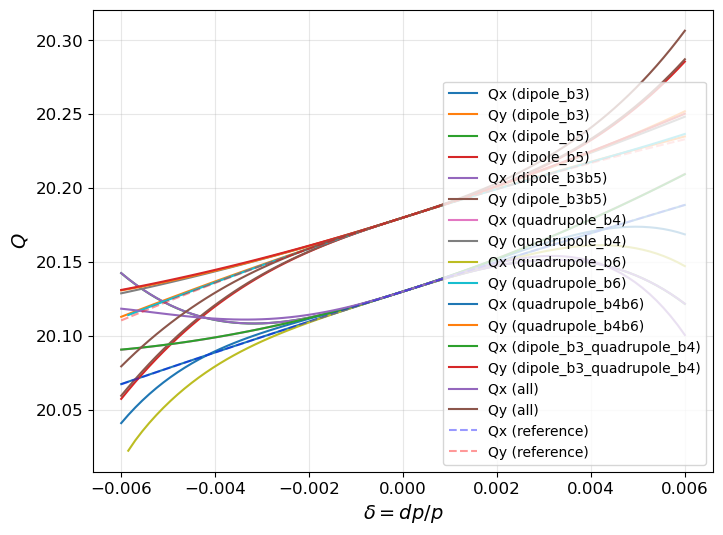

In [48]:
fig, ax = plt.subplots(figsize=(8, 6))

# Error model lines
# ax.plot(d, qx, label="Qx", color='blue', linestyle='-')
# ax.plot(d, qy, label="Qy", color='red', linestyle='-')

for tt in error_variants.keys():
    ax.plot(dds[tt], qxs[tt], label=f"Qx ({tt})", linestyle='-')
    ax.plot(dds[tt], qys[tt], label=f"Qy ({tt})", linestyle='-')

# Reference lines (lighter alpha)
ax.plot(d_ref, qx_ref, label="Qx (reference)", color='blue', alpha=0.4, linestyle='--')
ax.plot(d_ref, qy_ref, label="Qy (reference)", color='red', alpha=0.4, linestyle='--')

ax.tick_params(axis='both', labelsize=12)
# legend_elements = [
#     Line2D([0], [0], color='blue', label=r'$Q_x$'),
#     Line2D([0], [0], color='red', label=r'$Q_y$'),
#     Line2D([0], [0], color='gray', linestyle='-', label='Error model'),
#     Line2D([0], [0], color='gray', linestyle='--', alpha=0.4, label='Reference'),
# ]
# ax.legend(handles=legend_elements, fontsize=12, loc='upper left')
ax.legend()
ax.set_xlabel(r'$\delta = dp/p$', fontsize=14)
ax.set_ylabel(r'$Q$', fontsize=14)
ax.grid(True, alpha=0.3)

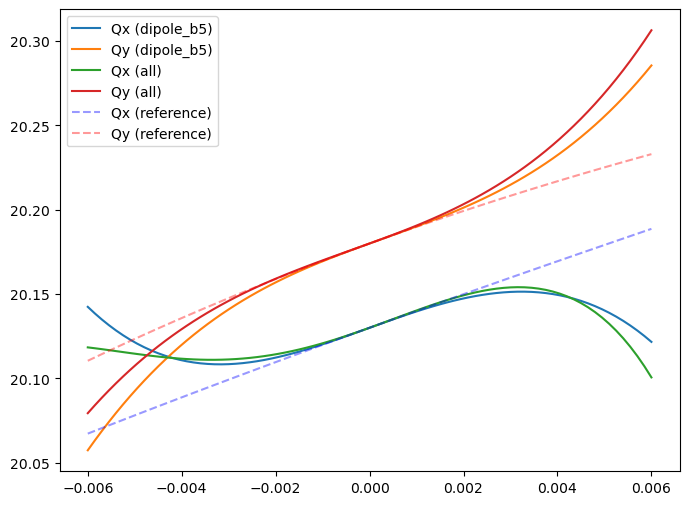

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))

# Error model lines
# ax.plot(d, qx, label="Qx", color='blue', linestyle='-')
# ax.plot(d, qy, label="Qy", color='red', linestyle='-')
tt = 'dipole_b5'
ax.plot(dds[tt], qxs[tt], label=f"Qx ({tt})", linestyle='-')
ax.plot(dds[tt], qys[tt], label=f"Qy ({tt})", linestyle='-')

tt = 'all'
ax.plot(dds[tt], qxs[tt], label=f"Qx ({tt})", linestyle='-')
ax.plot(dds[tt], qys[tt], label=f"Qy ({tt})", linestyle='-')

# Reference lines (lighter alpha)
ax.plot(d_ref, qx_ref, label="Qx (reference)", color='blue', alpha=0.4, linestyle='--')
ax.plot(d_ref, qy_ref, label="Qy (reference)", color='red', alpha=0.4, linestyle='--')

ax.legend()